In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report

# Configuration de l'affichage
sns.set_theme(style="whitegrid")

In [ ]:
df_raw = pd.read_csv('/kaggle/input/datasets/victorchen004/datascience/export.csv')

# Simulation de chargement
# df_raw doit avoir les colonnes : 'id', 'horodate', 'valeur'
print("Chargement des données...")

# Conversion de l'horodate en format datetime
df_raw['horodate'] = pd.to_datetime(df_raw['horodate'], utc=True)

# 2. Optionnel mais recommandé : on repasse à l'heure locale française (Europe/Paris)
# Cela permet d'avoir les bonnes heures pour différencier le jour et la nuit
df_raw['horodate'] = df_raw['horodate'].dt.tz_convert('Europe/Paris')

# Attention aux unités : on passe de la puissance (kW) sur 30 min à l'énergie (kWh)
df_raw['energie_kwh'] = df_raw['valeur'] * 0.5

# Extraction d'informations temporelles utiles
df_raw['mois'] = df_raw['horodate'].dt.month
df_raw['jour_semaine'] = df_raw['horodate'].dt.dayofweek # 0=Lundi, 6=Dimanche
df_raw['est_weekend'] = df_raw['jour_semaine'].isin([5, 6]).astype(int)
df_raw['heure'] = df_raw['horodate'].dt.hour
print("Étape 2 terminée avec succès !")

Chargement des données...
Étape 2 terminée avec succès !


In [3]:
# Agréger les données par client (id)
features = pd.DataFrame(index=df_raw['id'].unique())
features.index.name = 'id'

# 1. Consommation moyenne et écart-type globaux
features['conso_moyenne'] = df_raw.groupby('id')['energie_kwh'].mean()
features['conso_std'] = df_raw.groupby('id')['energie_kwh'].std()

# 2. Ratio de consommation Week-end vs Semaine
conso_we = df_raw[df_raw['est_weekend'] == 1].groupby('id')['energie_kwh'].mean()
conso_sem = df_raw[df_raw['est_weekend'] == 0].groupby('id')['energie_kwh'].mean()
features['ratio_we_semaine'] = conso_we / (conso_sem + 1e-5) # Eviter la division par zéro

# 3. Ratio de consommation Hiver vs Été (RES2 = chauffage électrique)
# Hiver : Nov à Mars (11, 12, 1, 2, 3) | Eté : Juin à Août (6, 7, 8)
hiver_mask = df_raw['mois'].isin([11, 12, 1, 2, 3])
ete_mask = df_raw['mois'].isin([6, 7, 8])

conso_hiver = df_raw[hiver_mask].groupby('id')['energie_kwh'].mean()
conso_ete = df_raw[ete_mask].groupby('id')['energie_kwh'].mean()
features['ratio_hiver_ete'] = conso_hiver / (conso_ete + 1e-5)

# 4. Proportion de temps à consommation quasi-nulle (typique d'une RS vide)
df_raw['conso_nulle'] = (df_raw['energie_kwh'] < 0.05).astype(int)
features['prop_conso_nulle'] = df_raw.groupby('id')['conso_nulle'].mean()

# Remplacer les éventuels NaN par 0
features = features.fillna(0)
print("Caractéristiques créées :", features.columns.tolist())

Caractéristiques créées : ['conso_moyenne', 'conso_std', 'ratio_we_semaine', 'ratio_hiver_ete', 'prop_conso_nulle']


In [4]:
# Normalisation des données
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Application de l'ACP (on conserve 95% de la variance expliquée)
pca = PCA(n_components=0.95, random_state=42)
features_pca = pca.fit_transform(features_scaled)

print(f"Nombre de composantes principales conservées : {features_pca.shape[1]}")

Nombre de composantes principales conservées : 4


Calcul des inerties et des scores de silhouette en cours...


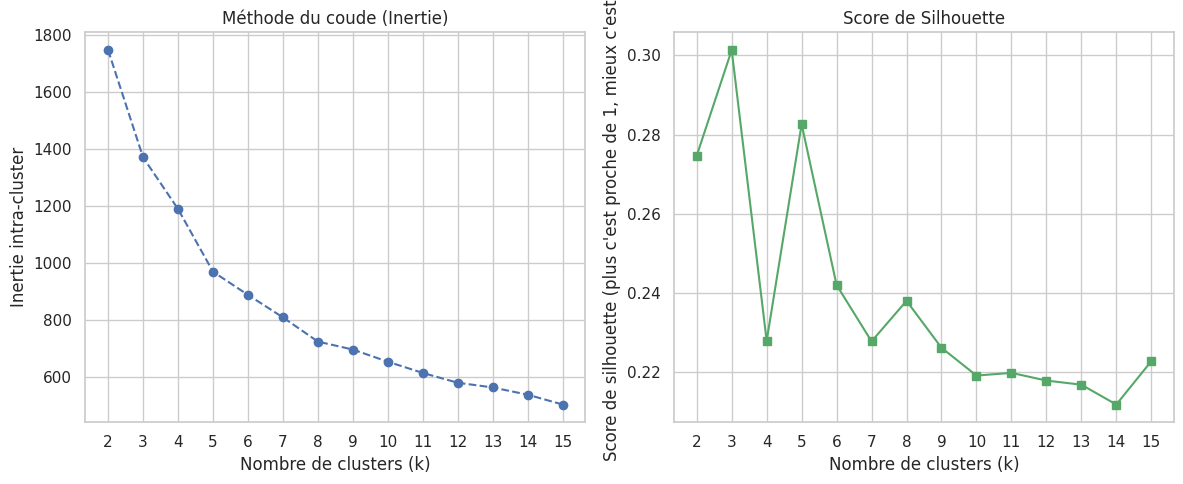

In [5]:
from sklearn.metrics import silhouette_score

# Plage de valeurs de k à tester (par exemple de 2 à 15 clusters)
K_range = range(2, 16)

inertias = []
silhouette_scores = []

print("Calcul des inerties et des scores de silhouette en cours...")

for k in K_range:
    # On instancie et on entraîne le modèle pour chaque k
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(features_pca)
    
    # On stocke l'inertie (Within-Cluster Sum of Square)
    inertias.append(kmeans.inertia_)
    
    # En bonus, on calcule le score de silhouette (mesure la qualité de séparation)
    score = silhouette_score(features_pca, kmeans.labels_)
    silhouette_scores.append(score)

# Création du graphique du coude
plt.figure(figsize=(12, 5))

# Graphique 1 : Inertie (Méthode du coude)
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o', linestyle='--', color='b')
plt.title('Méthode du coude (Inertie)')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie intra-cluster')
plt.xticks(K_range)
plt.grid(True)

# Graphique 2 : Score de silhouette
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='s', linestyle='-', color='g')
plt.title('Score de Silhouette')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Score de silhouette (plus c\'est proche de 1, mieux c\'est)')
plt.xticks(K_range)
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
# K-Means avec 12 clusters
kmeans = KMeans(n_clusters=12, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(features_pca)

# Ajout du cluster au dataframe des features
features['cluster'] = clusters

In [7]:
# Analyse des profils moyens des clusters pour assigner le label 0 ou 1
cluster_profiles = features.groupby('cluster').mean()

# On définit un seuil arbitraire (à ajuster selon vos observations)
# Exemple : si la proportion de temps à conso nulle > 40%, c'est une RS (label 1)
clusters_rs = cluster_profiles[cluster_profiles['prop_conso_nulle'] > 0.03].index.tolist()

# Création de la colonne label : 1 si le cluster est dans clusters_rs, 0 sinon
features['label'] = features['cluster'].apply(lambda c: 1 if c in clusters_rs else 0)

print("Profils des clusters :")
display(cluster_profiles[['conso_moyenne', 'prop_conso_nulle', 'ratio_we_semaine']])

Profils des clusters :


,conso_moyenne,prop_conso_nulle,ratio_we_semaine
cluster,,,
0,264.149233,0.030758,1.052491
1,318.268138,0.061841,1.054984
2,424.281284,0.015083,1.046969
3,335.690193,0.015684,1.145947
4,314.757608,0.014525,1.085770
5,377.786567,0.038659,1.044713
6,157.641049,0.298446,1.073331
7,337.573573,0.010816,1.028477
8,292.770204,0.218141,1.036022


In [8]:
# Analyse des profils moyens des clusters
cluster_profiles = features.groupby('cluster').mean()

# On ajuste le seuil en fonction de la réalité des données (ex: 0.03)
seuil_rs = 0.03

# On récupère la liste des clusters qui dépassent ce seuil
clusters_rs = cluster_profiles[cluster_profiles['prop_conso_nulle'] > seuil_rs].index.tolist()

# Création de la colonne label : 1 si c'est une RS, 0 sinon
features['label'] = features['cluster'].apply(lambda c: 1 if c in clusters_rs else 0)

print(f"Les clusters identifiés comme Résidences Secondaires (1) sont : {clusters_rs}")

Les clusters identifiés comme Résidences Secondaires (1) sont : [0, 1, 5, 6, 8]


In [9]:
# Préparation du dataframe final
output_df = features[['label', 'cluster']].reset_index()

# Sauvegarde en CSV
output_filename = 'RES2-6-9-labels-predictions.csv'
output_df.to_csv(output_filename, index=False)
print(f"Fichier sauvegardé avec succès sous : {output_filename}")

# Aperçu du résultat
output_df.head()

Fichier sauvegardé avec succès sous : RES2-6-9-labels-predictions.csv


,id,label,cluster
0,476866365062,0,3
1,47000903308,0,7
2,980841892564,0,10
3,917755392634,0,4
4,834037955197,0,2


In [10]:
# Sauvegarde du dataframe 'features' contenant nos variables, nos clusters et nos labels
# L'index contenant les 'id' des clients sera sauvegardé automatiquement
fichier_export = 'features_pour_classification.csv'
features.to_csv(fichier_export)

print(f"Les données prêtes pour la classification ont été sauvegardées dans {fichier_export}")

Les données prêtes pour la classification ont été sauvegardées dans features_pour_classification.csv
